In [1]:
import pandas as pd
import numpy as np
import warnings
from micom.workflows import load_results, GrowthResults
from micom.stats import compare_groups
import sys
import math

sys.path.append('..')
from utils import analysis

In [2]:
res = load_results('../goll_et.al_2020_IBS_FMT/models/res_western.zip')
ex_t0 = res.exchanges[(res.exchanges.sample_id.str.startswith('D') | res.exchanges.sample_id.str.endswith('-0'))].copy()
growth_t0 = res.growth_rates[(res.growth_rates.sample_id.str.startswith('D') | res.growth_rates.sample_id.str.endswith('-0'))].copy()
res_t0 = GrowthResults(growth_rates=growth_t0, exchanges=ex_t0, annotations=res.annotations.copy())
res_t0.exchanges['sample'] = res_t0.exchanges['sample_id'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient')
res_t0.growth_rates['sample'] = res_t0.growth_rates['sample_id'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient')

In [3]:
t0_production_rates = analysis.production_rates_with_imputation(res_t0)
t0_production_rates['sample'] = t0_production_rates['sample_id'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient')
total_t0_production = compare_groups(t0_production_rates, metadata_column='sample', groups=['donor', 'recipient'], threads=12, progress=True)

total_t0_production = (
    total_t0_production.merge(
        res_t0.annotations[['metabolite', 'name']],
        on='metabolite',
        how='left'
    )
    .assign(
        **{'-log10q_val': lambda x: -np.log10(x['q'])}
    )
)

total_t0_production['enrichment'] = total_t0_production.apply(lambda x: 'enriched' if (x['log_fold_change'] > 0 and x['q'] < 0.05) else ('depleted' if (x['log_fold_change'] < 0 and x['q'] < 0.05) else 'n.s.'), axis=1)
total_t0_production.to_csv('./data/2A.csv')
total_t0_production

Output()

,metabolite,log_fold_change,p,n,comparison,q,name,-log10q_val,enrichment
0,2omxyl[e],0.287688,0.403027,46,recipient vs. donor,0.865286,2-O-methylxylose (rare sugar in rhamnogalactur...,0.062840,n.s.
1,2omfuc[e],0.287688,0.403027,46,recipient vs. donor,0.865286,2-o-methylfucose (rare sugar in rhamnogalactur...,0.062840,n.s.
2,15dap[e],4.265102,0.039994,46,recipient vs. donor,0.233836,"1,5-Diaminopentane",0.631090,n.s.
3,2mbut[e],2.021394,0.000482,46,recipient vs. donor,0.007728,2-methylbutyrate,2.111921,enriched
4,2ddglcn[e],2.566558,0.080976,46,recipient vs. donor,0.427727,2-Dehydro-3-deoxy-D-gluconate,0.368833,n.s.
...,...,...,...,...,...,...,...,...,...
652,xan[e],0.251597,0.108957,46,recipient vs. donor,0.554921,Xanthine,0.255768,n.s.
653,xtsn[e],5.316972,0.002048,46,recipient vs. donor,0.024815,xanthosine,1.605292,enriched
654,val_L[e],-0.324254,0.000728,46,recipient vs. donor,0.010630,L-valine,1.973452,depleted
655,xyl_D[e],-0.782120,0.024534,46,recipient vs. donor,0.159589,aldehydo-D-xylose,0.796996,n.s.


In [4]:
metabolites_to_plot = {
    'Formate': 'for[e]', 
    'acetate': 'ac[e]', 
    'propionate': 'ppa[e]', 
    'butyrate': 'but[e]', 
    'Valeric Acid': 'M03134[e]', 
    'Sulfite': 'so3[e]', 
    'thiosulfate(2-)': 'tsul[e]', 
    'Methanethiol': 'ch4s[e]',
    'Hydrogen': 'h2[e]', 
}

ex_metabolites = res_t0.exchanges[res_t0.exchanges.metabolite.isin(metabolites_to_plot.values())].copy()
ex_metabolites = ex_metabolites.query('taxon != "medium" and direction == "export"')
ex_metabolites['flux'] = ex_metabolites['flux'] * ex_metabolites['abundance']
ex_metabolites = (
    ex_metabolites
    .groupby(['sample_id', 'metabolite'], as_index=False)
    .agg({'flux': 'sum'})
)

unique_samples = ex_metabolites['sample_id'].unique()
unique_metabolites = list(metabolites_to_plot.values())

template = pd.MultiIndex.from_product(
    [unique_samples, unique_metabolites],
    names=['sample_id', 'metabolite']
).to_frame(index=False)

template['sample'] = template['sample_id'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient')

ex_metabolites_complete = template.merge(
    ex_metabolites[['sample_id', 'metabolite', 'flux']], 
    on=['sample_id', 'metabolite'],
    how='left'  
).fillna(0)

id2metabolites = res_t0.annotations.set_index('metabolite')['name']
ex_metabolites_complete['name'] = ex_metabolites_complete['metabolite'].map(id2metabolites)

ex_metabolites_complete.to_csv('./data/2B.csv')

In [5]:
abundance_raw = pd.read_csv('../goll_et.al_2020_IBS_FMT/raw/goll_agora_map.counts.csv').set_index('taxon_id')
abundance_normalized_by_genome_length = pd.read_csv('../goll_et.al_2020_IBS_FMT/processed/abundance_normalized_table.csv').set_index('taxon_id')
DonorRecipientMapping = pd.read_csv('../goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')

donors = DonorRecipientMapping['donor'].str.split('_').str[0].unique().tolist()
recipients_T0 = DonorRecipientMapping['recipient'].str.split('_').str[0].unique().tolist()
recipients_T6 = [x.replace('-0', '-6') for x in recipients_T0]

recipients_T6 = set(recipients_T6).intersection(set(abundance_normalized_by_genome_length.columns))
recipients_T0 = [x.replace('-6', '-0') for x in recipients_T6]

all_samples = donors + recipients_T0 + list(recipients_T6)
final_samples = set(all_samples).intersection(set(abundance_normalized_by_genome_length.columns))

abundance_raw = abundance_raw.loc[:, abundance_raw.columns.isin(final_samples)]
abundance_normalized_by_genome_length = abundance_normalized_by_genome_length.loc[:, abundance_normalized_by_genome_length.columns.isin(final_samples)]

abundance_raw.to_csv('./data/abundance_raw_subset_unfiltered.csv')
abundance_normalized_by_genome_length.to_csv('./data/abundance_normalized_subset_unfiltered.csv')

abundance_normalized_by_genome_length_filtered = abundance_normalized_by_genome_length[(((abundance_normalized_by_genome_length / abundance_normalized_by_genome_length.sum(axis=0)) >= 0.0001).sum(axis=1) >= math.ceil((0.05 * abundance_normalized_by_genome_length.shape[1])))]
abundance_normalized_by_genome_length_filtered.to_csv('./data/abundance_normalized_subset_filtered.csv')

abundance_raw_filtered = abundance_raw.loc[abundance_raw.index.isin(abundance_normalized_by_genome_length_filtered.index), :]
abundance_raw_filtered.to_csv('./data/abundance_raw_subset_filtered.csv')

In [6]:
recipients = list(recipients_T6) + recipients_T0 + donors

growth_t6 = res.growth_rates[res.growth_rates.sample_id.isin(recipients)]
ex_t6 = res.exchanges[res.exchanges.sample_id.isin(recipients)]
res_t6 = GrowthResults(growth_rates=growth_t6, exchanges=ex_t6, annotations=res.annotations)

SCFA_to_plot = {
    'Formate': 'for[e]', 
    'acetate': 'ac[e]', 
    'propionate': 'ppa[e]', 
    'butyrate': 'but[e]', 
    'Valeric Acid': 'M03134[e]', 
}

DonorRecipientMapping = pd.read_csv('../goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')
DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient t0'] = DonorRecipientMapping['recipient'].str.split('_').str[0]
DonorRecipientMapping['recipient t6'] = DonorRecipientMapping['recipient t0'].str.replace('-0', '-6')
DonorRecipientMapping = DonorRecipientMapping.loc[
    DonorRecipientMapping['recipient t6'].isin(list(recipients_T6)), :
]

mapping = (
    DonorRecipientMapping[['clinical_response', 'recipient t0', 'recipient t6']]
    .melt(
        id_vars='clinical_response',
        value_vars=['recipient t0', 'recipient t6'],
        value_name='recipients'
    )
    .drop(columns=['variable'])
)

donor = (
    pd.DataFrame(
        'donor', 
        index=donors, 
        columns=['clinical_response']
    )
    .reset_index()
    .rename(columns={'index': 'recipients'})
)

mapping = pd.concat([mapping, donor], axis=0, ignore_index=True)
t6_production_rates = (
    analysis.production_rates_with_imputation(res_t6)
    .merge(
        mapping,
        left_on='sample_id',
        right_on='recipients',
        how='left'
    )
    .query('metabolite.isin(@SCFA_to_plot.values())')
    .assign(
        time=lambda x: np.where(
            x['sample_id'].str.endswith('-6'),
            'T6',
            'T0'
        )
    )
    .groupby(
        ['sample_id', 'time', 'clinical_response'],
        as_index=False
    )['flux'].sum()
)
t6_production_rates['base_sample_id'] = t6_production_rates['sample_id'].apply(lambda x: x if x.startswith('D') else x.split('-')[0])
t6_production_rates.to_csv('./data/2E.csv')

In [7]:
# create data for T0 donor, T0 recipient, and T6 recipient
res_western = load_results('../goll_et.al_2020_IBS_FMT/models/res_western.zip')
recipients_T6 = res_western.growth_rates[res_western.growth_rates.sample_id.str.endswith('-6')]['sample_id'].unique().tolist()
recipients_T0 = [x.replace('-6', '-0') for x in recipients_T6]
donors = res_western.growth_rates[res_western.growth_rates.sample_id.str.startswith('D')]['sample_id'].unique().tolist()
all_samples = donors + recipients_T0 + recipients_T6
res_western_growth_rate = (
    res_western.growth_rates[res_western.growth_rates.sample_id.isin(all_samples)]
    .copy()
)
res_western_exchange = (
    res_western.exchanges[res_western.exchanges.sample_id.isin(all_samples)]
    .copy()
)
res_western_filtered = GrowthResults(
    growth_rates=res_western_growth_rate, 
    exchanges=res_western_exchange, 
    annotations=res_western.annotations.copy()
)

key_metabolites = pd.read_csv('./data/2A.csv').query('q < 0.05')[['metabolite', 'enrichment']]

DonorRecipientMapping = pd.read_csv('../goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')[['recipient', 'clinical_response']]
DonorRecipientMapping['recipient'] = DonorRecipientMapping['recipient'].str.split('_').str[0].str.split('-').str[0] 
recipient_production_rates = (
    analysis.production_rates_with_imputation(
        res_western_filtered
    )
    .query('metabolite.isin(@key_metabolites["metabolite"]) and ~sample_id.str.startswith("D")')
    .assign(
        time=lambda x: np.where(
            x['sample_id'].str.endswith('-0'),
            'T0',
            'T6'
        ),
        base_sample_id=lambda x: x['sample_id'].str.split('-').str[0]
    )
    .merge(
        DonorRecipientMapping[['recipient', 'clinical_response']],
        left_on='base_sample_id',
        right_on='recipient',
        how='left'
    )
    .drop(columns=['recipient'])
    .dropna(subset=['clinical_response'])
    .merge(
        key_metabolites,
        on='metabolite',
        how='left'
    )
)
recipient_production_rates_t6 = recipient_production_rates.query('time == "T6"').rename(columns={'flux': 'flux_t6'})
recipient_production_rates_t0 = recipient_production_rates.query('time == "T0"').rename(columns={'flux': 'flux_t0'})
recipient_production_rates = (
    recipient_production_rates_t6.merge(
        recipient_production_rates_t0[['base_sample_id', 'metabolite', 'flux_t0']],
        on=['base_sample_id', 'metabolite'],
        how='left'
    )
)
recipient_production_rates['delta_flux'] = recipient_production_rates['flux_t6'] - recipient_production_rates['flux_t0']
recipient_production_rates = recipient_production_rates[['base_sample_id', 'metabolite', 'delta_flux', 'clinical_response']].rename(columns={'base_sample_id': 'sample_id'})
recipient_production_rates_pivoted = (
    recipient_production_rates.pivot_table(
        index=['sample_id'],
        columns='metabolite',
        values='delta_flux',
        fill_value=0.0
    )
)
X = recipient_production_rates_pivoted.values
X = np.log10(np.abs(X) + 1e-10)
y = recipient_production_rates_pivoted.index.map(DonorRecipientMapping.set_index('recipient')['clinical_response']).values
y = np.where(y == 'responder', 1, 0)

In [13]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
import numpy as np

# Initialize Repeated Stratified K-Fold
n_splits = 5 # Number of folds
n_repeats = 50  # Number of repetitions
rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

clf = RandomForestClassifier(random_state=0)

# Store metrics for all iterations
roc_auc_scores = []
f1_scores = []
accuracy_scores = []

tprs, fprs = {}, {}

# Perform Repeated Stratified K-Fold Cross-Validation
for fold_idx, (train_idx, test_idx) in enumerate(rskf.split(X, y)):
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Predict probabilities and classes
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    tpr, fpr, _ = roc_curve(y_test, y_pred_proba)

    # Store metrics
    roc_auc_scores.append(roc_auc)
    f1_scores.append(f1)
    accuracy_scores.append(accuracy)
    tprs[fold_idx] = tpr
    fprs[fold_idx] = fpr

# Calculate mean and standard deviation of metrics
mean_roc_auc = np.mean(roc_auc_scores)
std_roc_auc = np.std(roc_auc_scores)
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

# Print results
print(f"Repeated Stratified K-Fold Results ({n_splits} folds, {n_repeats} repeats):")
print(f"ROC AUC: {mean_roc_auc:.2f} ± {std_roc_auc:.2f}")
print(f"F1 Score: {mean_f1:.2f} ± {std_f1:.2f}")
print(f"Accuracy: {mean_accuracy:.2f} ± {std_accuracy:.2f}")

Repeated Stratified K-Fold Results (5 folds, 50 repeats):
ROC AUC: 0.85 ± 0.21
F1 Score: 0.80 ± 0.13
Accuracy: 0.69 ± 0.18


In [14]:
# perform a single fit and extract feature importances
clf.fit(X, y)
importances = clf.feature_importances_
feature_names = recipient_production_rates_pivoted.columns
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
feature_importances['importance'] = feature_importances['importance'] * 100
feature_importances = feature_importances.merge(
    res_western_filtered.annotations[['metabolite', 'name']],
    left_on='feature',
    right_on='metabolite',
    how='left'
).merge(
    key_metabolites,
    left_on='feature',
    right_on='metabolite',
    how='left'
).drop(columns=['metabolite_x', 'metabolite_y'])
feature_importances

,feature,importance,name,enrichment
0,bhb[e],7.894783,(R)-3-hydroxybutyrate,enriched
1,glcn[e],6.824444,D-gluconate,enriched
2,hxan[e],6.531671,Hypoxanthine,enriched
3,o2[e],5.574918,O2,enriched
4,h2[e],4.664561,Hydrogen,enriched
...,...,...,...,...
62,isobut[e],0.000000,"Isobutyrate, 2-Methylpropanoate",enriched
63,cholate[e],0.000000,Cholate,enriched
64,ddca[e],0.000000,laurate,enriched
65,adn[e],0.000000,Adenosine,depleted


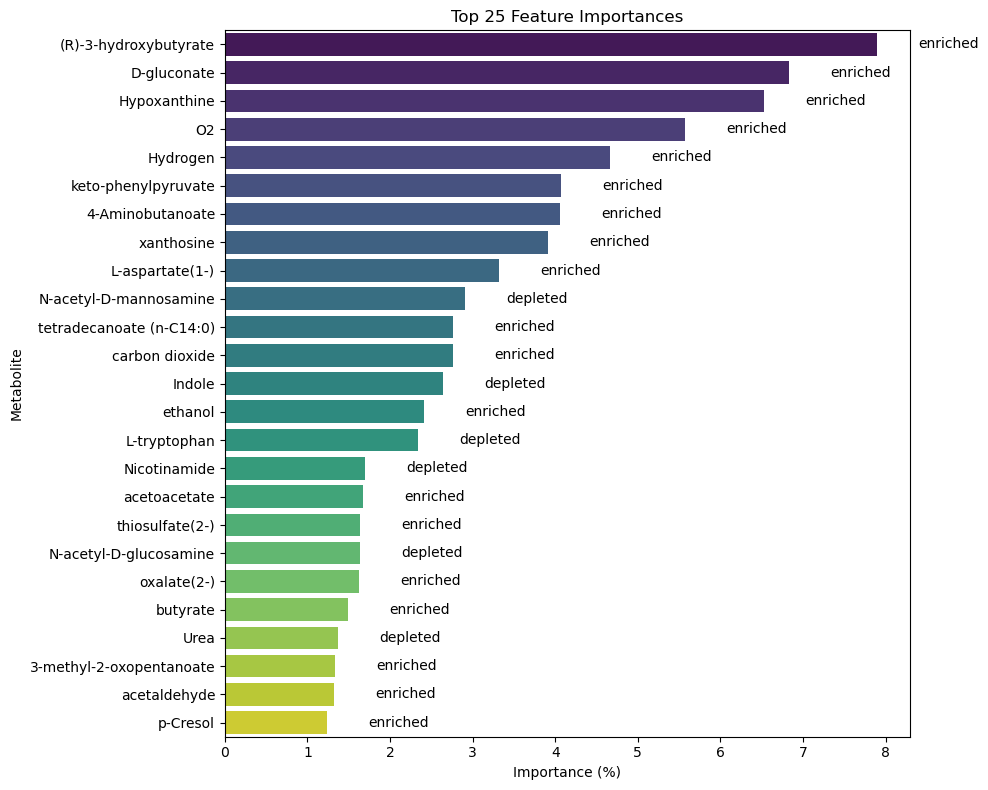

In [16]:
# plot the top 30 feature importances
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
top_n = 25
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importances.head(top_n),
    x='importance',
    y='name',
    palette='viridis'
)
# label bars with enrichment status
for index, row in feature_importances.head(top_n).iterrows():
    plt.text(
        row['importance'] + 0.5,
        index,
        row['enrichment'],
        va='center'
    )
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance (%)')
plt.ylabel('Metabolite')
plt.tight_layout()

In [11]:
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import numpy as np

# Assuming X and y are already defined in the main script
# Perform Leave-One-Out Cross-Validation
loo = LeaveOneOut(
clf = RandomForestClassifier(random_state=42)

# Store metrics for each iteration
roc_auc_scores = []
f1_scores = []
accuracy_scores = []

for train_idx, test_idx in loo.split(X):
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Predict probabilities and classes
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    if len(np.unique(y_test)) > 1:  # Check if y_test has more than one class
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        roc_auc_scores.append(roc_auc)
    else:
        roc_auc_scores.append(np.nan)  # Append NaN if ROC AUC cannot be calculated
    
    f1 = f1_score(y_test, y_pred, zero_division=0)  # Handle division by zero
    accuracy = accuracy_score(y_test, y_pred)
    
    f1_scores.append(f1)
    accuracy_scores.append(accuracy)

# Calculate mean and standard deviation of metrics
mean_roc_auc = np.nanmean(roc_auc_scores)  # Use np.nanmean to ignore NaN values
std_roc_auc = np.nanstd(roc_auc_scores)
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

# Print results
print(f"Leave-One-Out Cross-Validation Results:")
print(f"ROC AUC: {mean_roc_auc:.2f} ± {std_roc_auc:.2f}")
print(f"F1 Score: {mean_f1:.2f} ± {std_f1:.2f}")
print(f"Accuracy: {mean_accuracy:.2f} ± {std_accuracy:.2f}")

SyntaxError: invalid syntax (1198840003.py, line 12)